# K-Means Clustering from Scratch: A Step-by-Step Guide

This Jupyter Notebook will walk you through implementing the K-Means clustering algorithm from the ground up. 

## Section 1: Setup and Introduction

### What is K-Means?

K-Means is one of the most popular "unsupervised" machine learning algorithms. "Unsupervised" means we don't have pre-defined labels for our data. The goal of K-Means is to find groups (clusters) in the data, with the number of groups being represented by the variable `k`.

The algorithm works in an iterative way:

1. **Initialise:** Randomly place `k` "centroids" (cluster centers) on the data.

2. **Assign:** Assign each data point to its *closest* centroid. This forms `k` clusters.

3. **Update:** Move each centroid to the *center (mean)* of all the data points assigned to it.

4. **Repeat:** Repeat steps 2 and 3 until the centroids stop moving.

Let's build this from scratch.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

ModuleNotFoundError: No module named 'matplotlib'

## Section 2: Generate and Visualize Our Data

First, we need some data to cluster. We'll use `scikit-learn`'s `make_blobs` function to generate 2D data that has three distinct, visible groups. Our goal will be to see if our algorithm can find them.

In [2]:
# Load the credit card dataset
df = pd.read_csv("Credit_Card_Dataset.csv")

# Choose which numeric features to cluster on (2D for easy plotting)
features = ["Annual_Income", "Credit_Score"]
X = df[features].values  # this keeps the name X the same as before

print("Data shape:", X.shape)
print("Features used:", features)
# X is now (n_samples, 2), where:
#   X[:, 0] = Annual_Income
#   X[:, 1] = Credit_Score

NameError: name 'make_blobs' is not defined

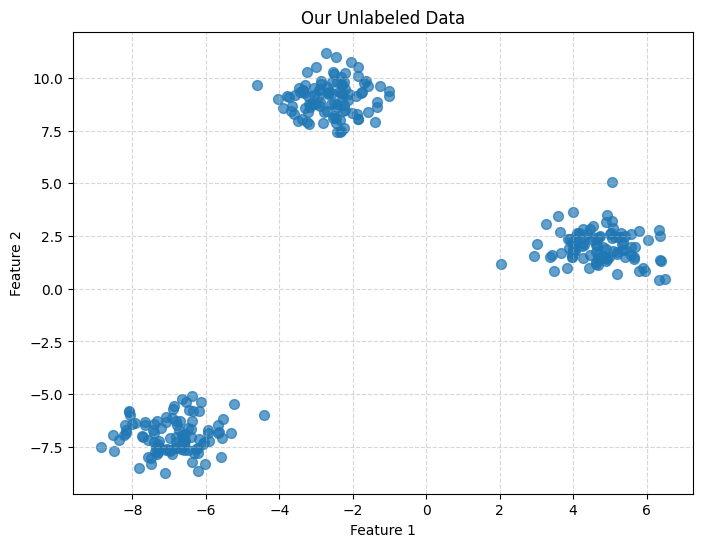

In [100]:
# Plot the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.7)
plt.title("Our Unlabeled Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Section 3: Building the Algorithm

This is where we build the logic piece by piece.

### Step 1 - Initlialise the algorithm

First, we need to decide on `k` (the number of clusters) and then randomly initialize our `k` centroids. A common way to do this is to just pick `k` random points *from our dataset* `X` to be the initial centroids.

Let's set `k = 3`.

Initial (random) centroids:
[[-6.61377598 -7.47889882]
 [ 5.80079372  2.74058634]
 [-6.73413419 -6.68153312]]


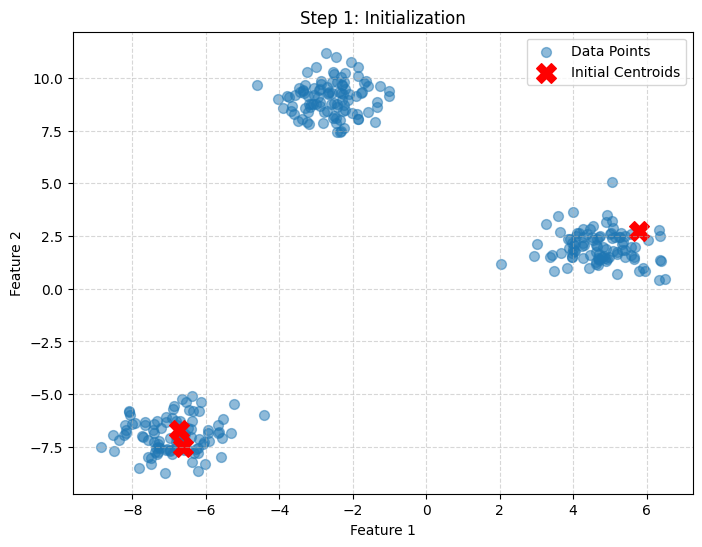

In [114]:
# Set k
k = 3

# Get the number of samples (n) and features (d)
n_samples, n_features = X.shape

# --- This is the key logic ---
# 1. Get k random indices from 0 to n_samples-1
random_indices = np.random.choice(n_samples, k, replace=False)

# 2. Select the points at those indices as our initial centroids
centroids = X[random_indices]
# ------------------------------

print("Initial (random) centroids:")
print(centroids)

# Plot the data and our initial centroids
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.5, label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Initial Centroids')
plt.title("Step 1: Initialization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 2 - The Assignment Step

Now, for *each* data point, we need to find out which of the three red 'X's it's closest to. We'll use **Euclidean distance** for this.

`distance = sqrt((x1 - c1)^2 + (y1 - c2)^2)`

We'll create an array called `labels` that stores the "cluster index" (0, 1, or 2) for every single point.

In [5]:
squares = [(X[0] - centroid)**2 for centroid in centroids]
squares

[array([130.31370741, 104.30202836]),
 array([0.21504108, 1.19121194]),
 array([146.6954144 ,  81.63113749])]

In [6]:
distances = [np.sqrt(x + y) for x, y in squares]
distances

[np.float64(15.317171271782621),
 np.float64(1.1858553985749787),
 np.float64(15.110478214982017)]

In [7]:
np.argmin(distances)

np.int64(1)

First 10 labels: [0 0 1 1 0 1 1 1 1 1]


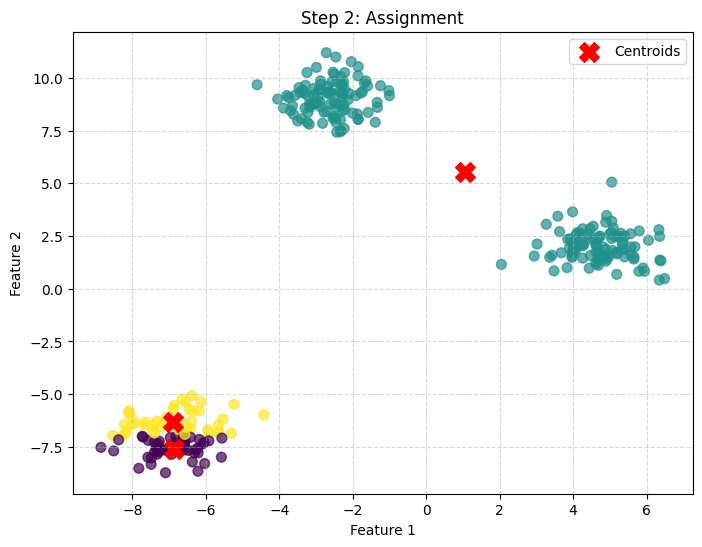

In [119]:
# --- This is the key logic ---
# We'll build the labels array
labels = np.zeros(n_samples, dtype=int)

# Loop over each data point
for i in range(n_samples):
    point = X[i]
    
    # Calculate the distance from this point to each of the k centroids
    squares = [(point - centroid)**2 for centroid in centroids]
    distances = [np.sqrt(x + y) for x, y in squares]

    # Find the index (0, 1, or 2) of the *closest* centroid
    closest_centroid_index = np.argmin(distances)
    
    # Assign that index as the label for this point
    labels[i] = closest_centroid_index
# ------------------------------

print("First 10 labels:", labels[:10])

# Now, let's plot the data again, but color-coded by our new labels
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, alpha=0.7, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title("Step 2: Assignment")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 3 - The Update Step

Our centroids are still in their old random positions. We need to "update" them by moving them to the *mean* (the average x and y) of all the points assigned to them.

For example, to get the new "centroid 0":

1. Find all points where `labels == 0`.

2. Calculate the average `x` and average `y` of those points.

3. That `(avg_x, avg_y)` is our new centroid.

Old centroids:
 [[-6.87847567 -7.60443972]
 [ 1.0586164   5.5204112 ]
 [-6.88757007 -6.32197876]]

New centroids:
 [[-6.9090054  -7.5708119 ]
 [ 1.0586164   5.5204112 ]
 [-6.85372342 -6.27804027]]


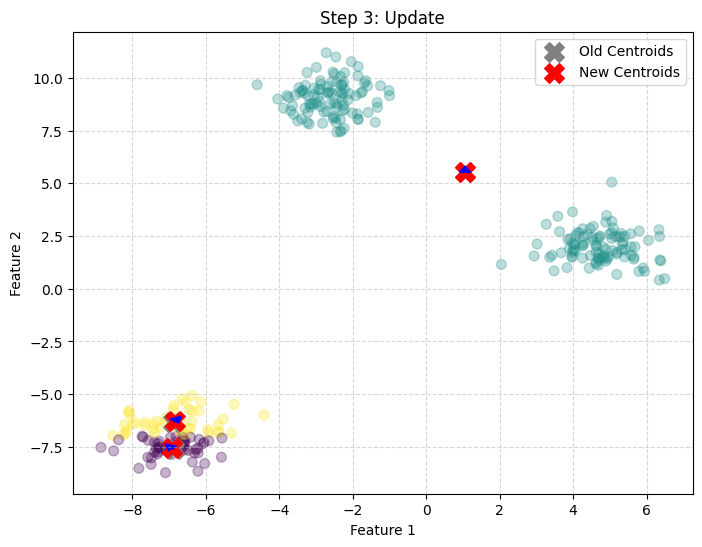

In [120]:
# Store the old centroids so we can see them move
old_centroids = np.copy(centroids)

# --- This is the key logic ---
# Create an array to store the new centroids
new_centroids = np.zeros((k, n_features))

# Loop over each cluster index (0, 1, and 2)
for i in range(k):
    # 1. Get all points assigned to this cluster
    points_in_cluster = X[labels == i]
    
    # 2. Calculate the mean of these points
    # We check if points_in_cluster is not empty to avoid errors
    if len(points_in_cluster) > 0:
        new_centroids[i] = np.mean(points_in_cluster, axis=0)
# ------------------------------

# Update our main 'centroids' variable
centroids = new_centroids

print("Old centroids:\n", old_centroids)
print("\nNew centroids:\n", centroids)

# Plot the movement
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, alpha=0.3, cmap='viridis')

# Plot old centroids (faded)
plt.scatter(old_centroids[:, 0], old_centroids[:, 1], s=200, c='gray', marker='X', label='Old Centroids')
# Plot new centroids (bold)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='New Centroids')

# Draw arrows showing the movement
for i in range(k):
    plt.arrow(old_centroids[i, 0], old_centroids[i, 1],
              centroids[i, 0] - old_centroids[i, 0],
              centroids[i, 1] - old_centroids[i, 1],
              head_width=0.3, head_length=0.3, fc='blue', ec='blue')

plt.title("Step 3: Update")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Section 4: The Actual Implementation (Putting It All Together)

We've successfully run one full "iteration" (Assign -> Update). Now we need to:

1. Put this logic inside a loop that runs for a set number of iterations (e.g., 100) or until the centroids stop moving.

2. Wrap all this logic into a Python class to make it clean and reusable.

We'll create a class called `MyKMeans` that has a `.fit()` method (to do the training) and a `.predict()` method (to assign new points).

In [96]:
class MyKMeans:
    """
    A simple K-Means implementation from scratch.
    """
    
    def __init__(self, k, max_iter=100, random_state=42):
        self.k = k
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None # Will store final centroids
        self.labels = None    # Will store final labels for training data
        np.random.seed(self.random_state)

    def _initialize_centroids(self, X):
        """Randomly selects k points from X as initial centroids."""
        n_samples, _ = X.shape
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        print(random_indices)
        self.centroids = X[random_indices]

    def _assign_clusters(self, X):
        """Assigns each point in X to the closest centroid."""
        n_samples, _ = X.shape
        labels = np.zeros(n_samples, dtype=int)
        
        for i in range(n_samples):
            point = X[i]
            squares = [(point - centroid)**2 for centroid in self.centroids]
            distances = [np.sqrt(x + y) for x, y in squares]

            labels[i] = np.argmin(distances)
        
        return labels

    def _update_centroids(self, X, labels):
        """Calculates the new centroids as the mean of assigned points."""
        _, n_features = X.shape
        new_centroids = np.zeros((self.k, n_features))
        
        for i in range(self.k):
            points_in_cluster = X[labels == i]
            if len(points_in_cluster) > 0:
                new_centroids[i] = np.mean(points_in_cluster, axis=0)
        
        return new_centroids

    def fit(self, X):
        """
        Runs the K-Means algorithm (Initialization, then iterative Assignment and Update).
        """
        # --- Step 1: Initialization ---
        self._initialize_centroids(X)
        
        # --- Iteration (Steps 2 & 3) ---
        for _ in range(self.max_iter):
            # Store old centroids to check for convergence
            old_centroids = np.copy(self.centroids)
            
            # --- Step 2: Assignment ---
            self.labels = self._assign_clusters(X)
            
            # --- Step 3: Update ---
            self.centroids = self._update_centroids(X, self.labels)
            
            # --- Check for convergence ---
            # If the centroids didn't move, we're done!
            if np.all(old_centroids == self.centroids):
                break
                
        print(f"Algorithm converged after {_ + 1} iterations.")

    def predict(self, X):
        """
        Assigns new data points to the clusters found during fit.
        This is just the 'Assignment' step, using the *final* centroids.
        """
        if self.centroids is None:
            raise Exception("Model not fitted yet. Call .fit() first.")
            
        return self._assign_clusters(X)

Now, let's *use* our new class. It's as simple as creating an instance and calling `.fit()` on our data `X`.

[ 24  65 113]
Algorithm converged after 5 iterations.

Final Centroids:
 [[-2.60842567  9.03771305]
 [-6.88302287 -6.96320924]
 [ 4.72565847  2.00310936]]


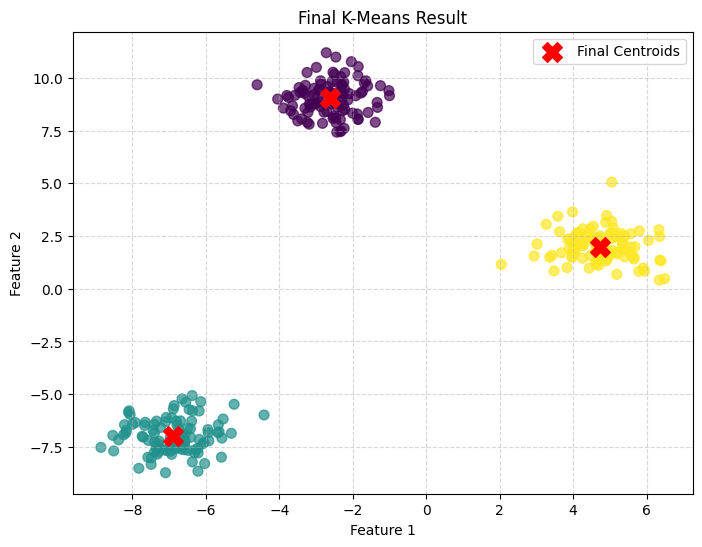

In [97]:
# 1. Create an instance of our class
kmeans = MyKMeans(k=3, max_iter=100, random_state=10)

# 2. Run the algorithm
kmeans.fit(X)

# 3. Get the final results
final_labels = kmeans.labels
final_centroids = kmeans.centroids

print("\nFinal Centroids:\n", final_centroids)

# 4. Plot the final clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_labels, s=50, alpha=0.7, cmap='viridis')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], s=200, c='red', marker='X', label='Final Centroids')
plt.title("Final K-Means Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Section 5: Discussion and Further Challenges

Our algorithm successfully found the three clusters!

But K-Means isn't perfect. Here are some key discussion points:

1. **The Initialization Problem:** The final clusters *depend* on the random starting points. A bad start can lead to a "sub-optimal" clustering (a *local minimum*).

   * **Challenge:** Run `MyKMeans(k=3, random_state=10)` (a different seed). Does the result change? (It might!). This is why `sklearn`'s K-Means runs the algorithm multiple times with different random starts (`n_init=10`) and picks the best one.

2. **The `k` Problem:** We *knew* to set `k=3` because we made the data. In the real world, you don't know `k`.

   * **Challenge:** How would you find the best `k`? This leads to the **"Elbow Method,"** where you run K-Means for many different `k` values (e.g., 1 to 10) and plot a "score" (called *inertia*) for each `k`. The "elbow" of the plot is often the best `k`.

3. **Cluster Shape:** K-Means assumes clusters are spherical and roughly the same size. It fails badly on data with complex shapes (like moons or circles).

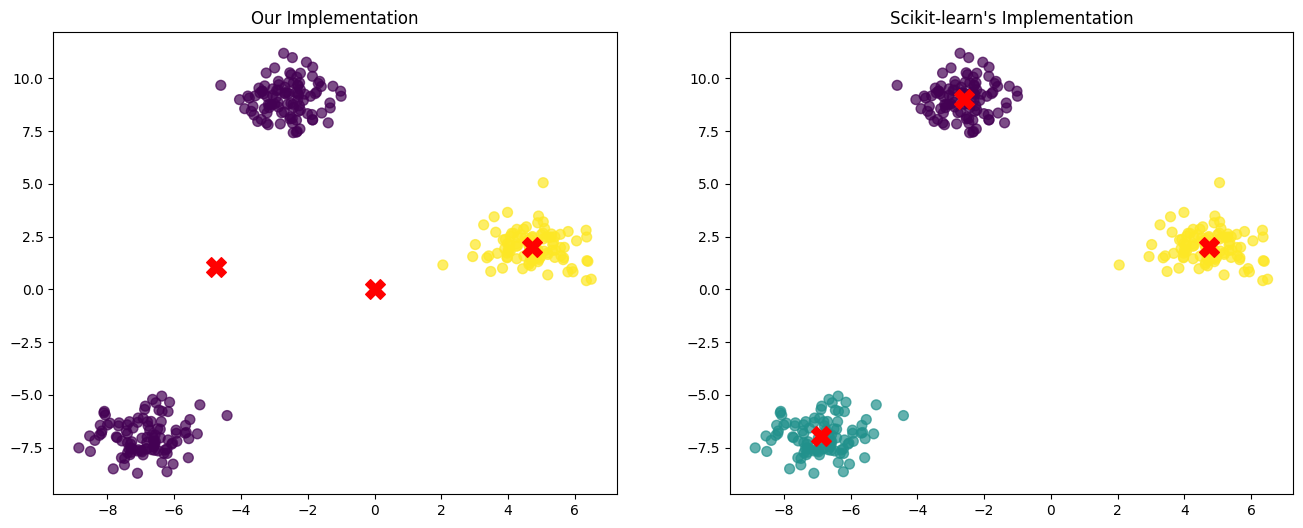

In [90]:
from sklearn.cluster import KMeans as SklearnKMeans

# Run sklearn's version
sklearn_kmeans = SklearnKMeans(n_clusters=3, random_state=42, n_init=10)
sklearn_kmeans.fit(X)
sk_labels = sklearn_kmeans.labels_
sk_centroids = sklearn_kmeans.cluster_centers_

# Plot our result vs. sklearn's
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(X[:, 0], X[:, 1], c=final_labels, s=50, alpha=0.7, cmap='viridis')
ax1.scatter(final_centroids[:, 0], final_centroids[:, 1], s=200, c='red', marker='X')
ax1.set_title("Our Implementation")

ax2.scatter(X[:, 0], X[:, 1], c=sk_labels, s=50, alpha=0.7, cmap='viridis')
ax2.scatter(sk_centroids[:, 0], sk_centroids[:, 1], s=200, c='red', marker='X')
ax2.set_title("Scikit-learn's Implementation")

plt.show()

**Assignment:** Research the **Elbow Method** and apply it to this problem.